In [27]:
"""Settings related to escape pattern analysis."""
Path = r'Z:\Jasmine_Laurence\Experimental_Data\JAL006\JAL006_shelter_barrier_flip_3_2024_03_21T11_20_34\processed_data\models\replay\replay_state_space_decoder\before_homing_shelter_only\SSdata_bin1.0ms_train_homing&escape_test_before_homing.npz'
settings_file = Path.replace('.npz', '_settings.npz')
save_file = Path.replace('.npz', '_replay_results.npz')      

In [30]:
"""Imports"""
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
np.warnings = warnings
from replay_trajectory_classification import SortedSpikesDecoder, Environment, RandomWalk, estimate_movement_var

In [ ]:
# load data
data = np.load(Path)
settings = np.load(settings_file, allow_pickle=True)
settings = settings['settings'].item()
sampling_frequency = 1000 / settings['replay_state_space_decoder_bin_size'] # in Hz, bin_width is in ms

# set up environment parameters
linear_track_env = Environment(
                            place_bin_size=1,  # Adjust based on your actual bin size
                            # track_graph=my_linear_graph,  # Define a linear graph with 25 nodes
                            edge_order=[(i, i + 1) for i in range(24)],  # Sequential edges
                            edge_spacing=None,  # No gaps between edges
                            position_range=[(0, 25)],  # 0 to 100% of escape route
                            infer_track_interior=False,  # Data is already binned
                            fill_holes=False,
                            dilate=False,
                            bin_count_threshold=1,
                        )

transition_type = RandomWalk(movement_var=1)

decoder = SortedSpikesDecoder(
                            environment=linear_track_env,
                            transition_type=transition_type,
                            sorted_spikes_algorithm='spiking_likelihood_kde',
                            sorted_spikes_algorithm_params={'block_size': None,
                                                            'position_std': [1.0],
                                                            'use_diffusion': False},
                        )

decoder.fit(data['train_position'], data['train_spikes'])

test_results = decoder.predict(data['test_spikes'], time=data['test_time'])
train_results = decoder.predict(data['train_spikes'], time=data['train_time'])

# save results

np.savez(save_file,
         test_causal_posterior=test_results.causal_posterior,
         test_acausal_posterior=test_results.acausal_posterior,
         train_causal_posterior=train_results.causal_posterior,
         train_acausal_posterior=train_results.acausal_posterior)

100%|██████████| 117/117 [00:02<00:00, 48.15it/s]


100%|██████████| 117/117 [00:02<00:00, 39.95it/s]


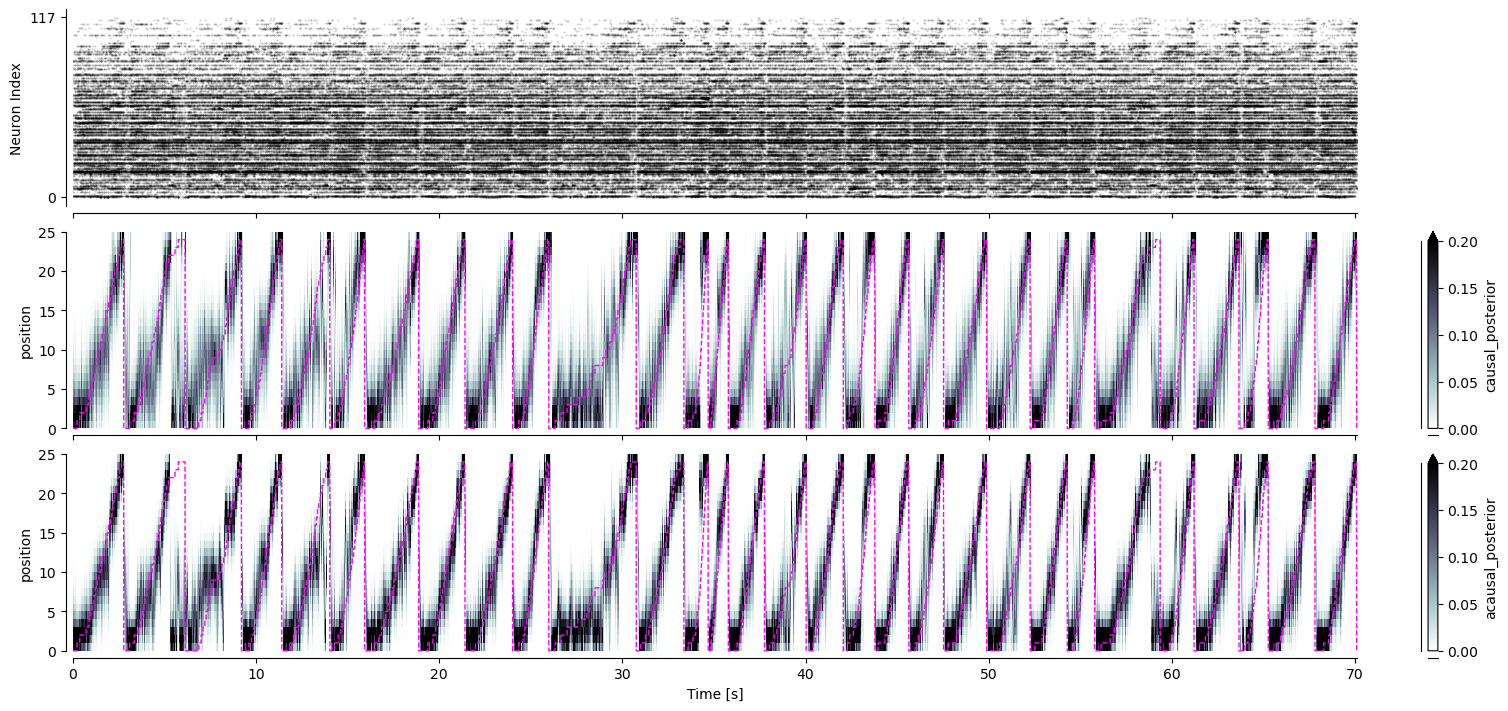

In [32]:
"""Plot train data predictions from decoder"""
# use only either causal or acausal posterior for plotting
# also plot the actual run trajectory?

fig, axes = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(15, 7))

spike_time_ind, neuron_ind = np.nonzero(data['train_spikes'])
ax0 = axes[0]
ax0.scatter(data['train_time'][spike_time_ind], neuron_ind, color='black', s=.2, alpha = .2, zorder = 1)
ax0.set_yticks((0, data['train_spikes'].shape[1]))
ax0.set_ylabel('Neuron Index')

train_results.causal_posterior.plot(x="time", y="position", ax=axes[1], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[1].plot(data['train_time'], data['train_position'], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes[1].set_xlabel("")
train_results.acausal_posterior.plot(x="time", y="position", ax=axes[2], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[2].plot(data['train_time'], data['train_position'], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes[2].set_xlabel('Time [s]')

sns.despine(offset=5)

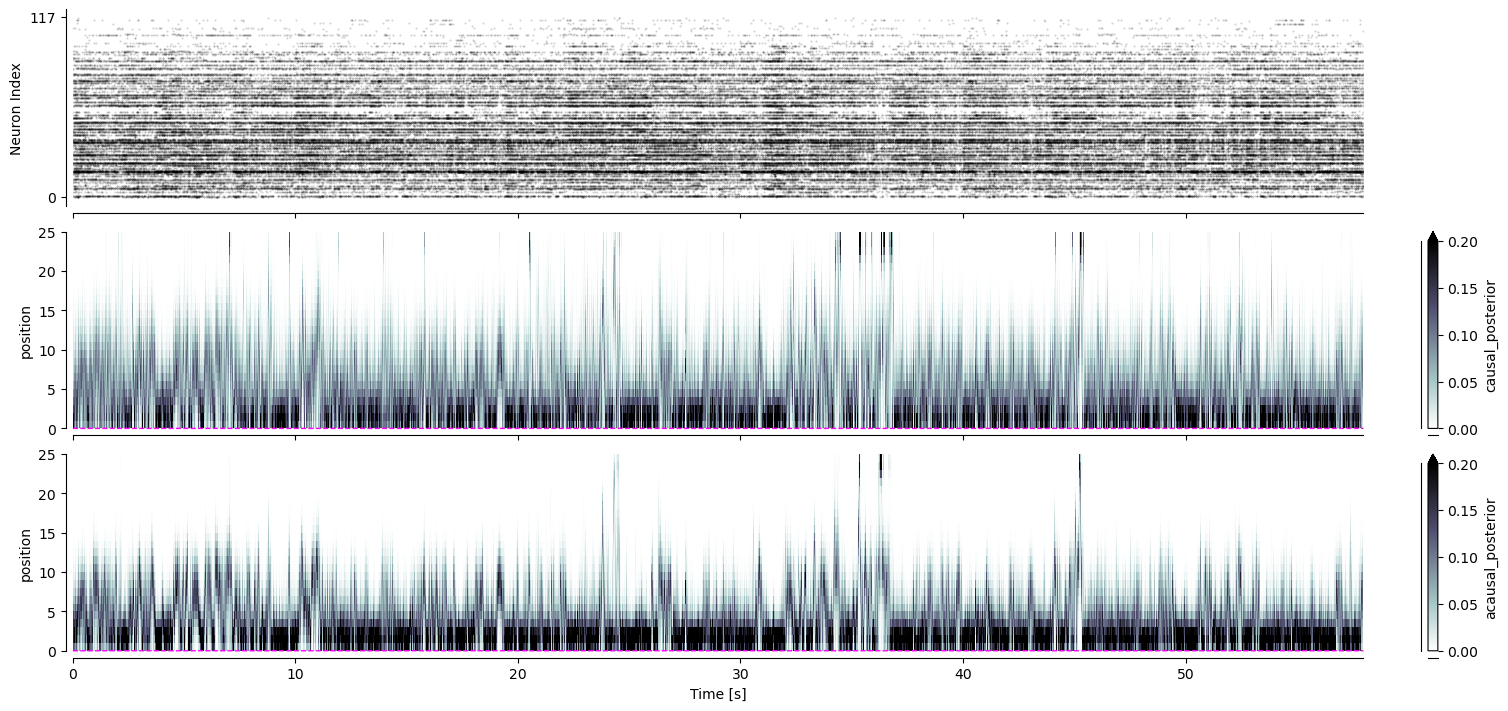

In [ ]:
"""Plot test data predictions from decoder"""
# use only either causal or acausal posterior for plotting
# also plot the actual run trajectory?

fig, axes = plt.subplots(3, 1, sharex=True, constrained_layout=True, figsize=(15, 7))

spike_time_ind, neuron_ind = np.nonzero(data['test_spikes'])
ax0 = axes[0]
ax0.scatter(data['test_time'][spike_time_ind], neuron_ind, color='black', s=.2, alpha = .2, zorder = 1)
ax0.set_yticks((0, data['test_spikes'].shape[1]))
ax0.set_ylabel('Neuron Index')

test_results.causal_posterior.plot(x="time", y="position", ax=axes[1], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[1].plot(data['test_time'], data['test_position'], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes[1].set_xlabel("")
test_results.acausal_posterior.plot(x="time", y="position", ax=axes[2], cmap="bone_r", vmin = 0, vmax = .2, clip_on=False)
axes[2].plot(data['test_time'], data['test_position'], color="magenta", linestyle="--", linewidth=1, clip_on=False)
axes[2].set_xlabel('Time [s]')

sns.despine(offset=5)

In [ ]:
"""Look at the actual and decoder tuning curves"""
# need to load the tuning curves!!
g = (decoder.place_fields_ * sampling_frequency).plot(
        x="position", col="neuron", col_wrap=5, color="red", linewidth=2, alpha=0.9, zorder=1, label="Predicted")
g.axes[0, 0].set_ylabel("Firing Rate [spikes/s]")
for ax, place_field in zip(g.axes.flat, tuning_curves):
    ax.plot(np.arange(25), place_field, linewidth=2, color="black", zorder=-1, label="True")
sns.despine()